In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import torch
import argparse
import yaml
from numba import cuda
import zuko



In [2]:
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d

In [3]:
SEED = 8
NUM_COND_INPUTS = 0
BIN_BOUND = 5
NUM_BINS = 100
BATCH_SIZE = 512
NUM_EPOCHS = 5
PLOT_EPOCH_INTERVAL = 1
NUM_FEATURES = 5
ZUKO_ID = "NSF"



In [4]:
save_dir = ZUKO_ID
os.makedirs(ZUKO_ID, exist_ok=True)

In [5]:

# computing
device = cuda.get_current_device()
device.reset()
torch.set_num_threads(2)
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)
seed = int(SEED)
torch.manual_seed(seed)
np.random.seed(seed)

Using device: cuda


In [6]:
collections_TrackerHitPlane = [
    "IBTrackerHits",
    "IBTrackerHitsConed",
    "IETrackerHits", 
    "IETrackerHitsConed",
    "OBTrackerHits",
    "OBTrackerHitsConed", 
    "OETrackerHits",        
    "OETrackerHitsConed",          
    "VBTrackerHits",               
    "VBTrackerHitsConed",   
    "VETrackerHits",  
    "VETrackerHitsConed",        
]

collections_SimTrackerHit = [
  #  "InnerTrackerBarrelCollection",
   # "InnerTrackerBarrelCollectionConed",
 #   "InnerTrackerEndcapCollection",
    #"InnerTrackerEndcapCollectionConed", 
    "OuterTrackerBarrelCollection",     
   # "OuterTrackerBarrelCollectionConed",
 #   "OuterTrackerEndcapCollection",  
   # "OuterTrackerEndcapCollectionConed",
 #   "VertexBarrelCollection",   
   # "VertexBarrelCollectionConed",   
  #  "VertexEndcapCollection",
   # "VertexEndcapCollectionConed",
]



feature_labels = ["$E$", "$x$", "$y$", "$z$", "$t$", "context"]
log_vars = []

In [7]:

data = []
context = []

for i, collection in enumerate(collections_SimTrackerHit): # TODO coned too?

    tmp_data = np.load(f"/pscratch/sd/r/rmastand/muon/npys/{collection}_SimTrackerHit.npy")
    tmp_context = int(i)*np.ones((tmp_data.shape[0],1))
    context.append(tmp_context)
    data.append(tmp_data[:int(len(tmp_data)*.1)])


data = np.vstack(data)[:,[0,2,3,4,5]]
data = data[data[:,0] > 2e-6]
data[:,0] = np.log(data[:,0])
context = np.vstack(context)



bins_dict = {}
bins_dict_preproc = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(data.shape[1])}

for i in range(data.shape[1]):
    if i in log_vars:
        bins_dict[i] = np.logspace(np.log10(0.9*np.min(data[:,i])), np.log10(1.1*np.max(data[:,i])), 100) 
    else:
        bins_dict[i] = np.linspace(np.min(data[:,i] - 10), np.max(data[:,i] + 10), 100) 


In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle

def preprocess_data(X, flow_training_dir, eps=1e-12):
    """
    Preprocess data without modifying the original array.
    Applies log to the first column and standardizes all columns.
    """
    
    # standardize all columns
    standard_scaler = StandardScaler()
    X_preproc = standard_scaler.fit_transform(X)

    # save scaler for inverse transform
    with open(f"{flow_training_dir}/standard", "wb") as ofile:
        pickle.dump(standard_scaler, ofile)

    return X_preproc


def inverse_preprocess_data(X_preproc, flow_training_dir, eps=1e-12):
    """
    Inverse preprocessing without modifying the input array.
    Inverts standardization and applies exp to the first column.
    """
    # load scaler
    with open(f"{flow_training_dir}/standard", "rb") as ifile:
        standard_scaler = pickle.load(ifile)

    # inverse standardization
    X_inv = standard_scaler.inverse_transform(X_preproc)



    return X_inv


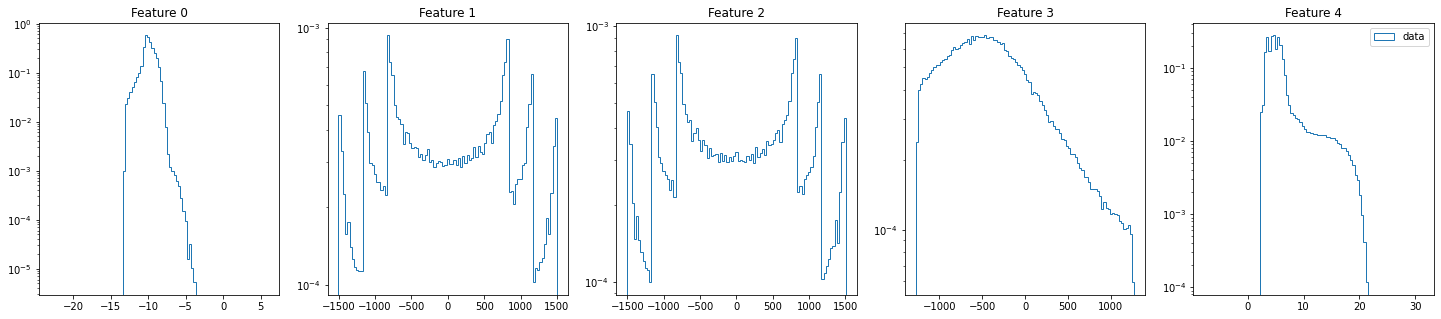

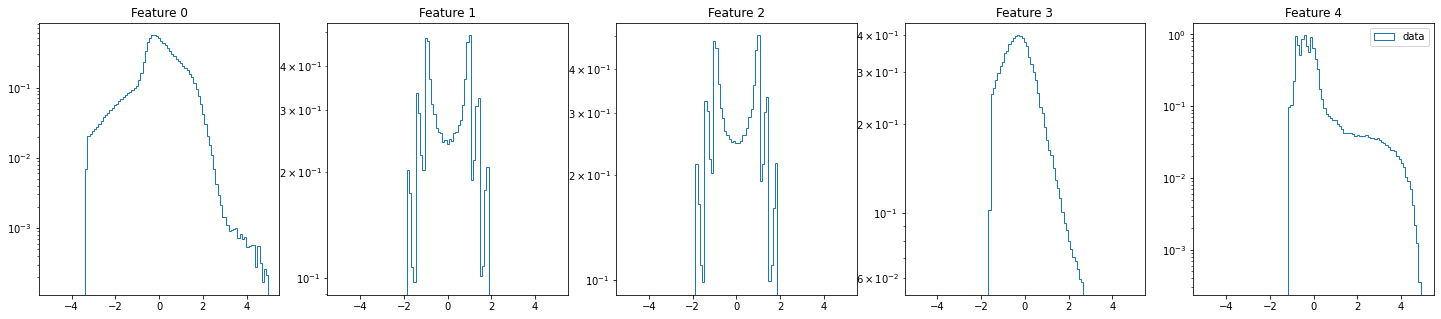

In [9]:


X_preproc = preprocess_data(data, ".")
if NUM_COND_INPUTS == 1:
    X_preproc = np.hstack([X_preproc,  context])
elif NUM_COND_INPUTS == 0:
    pass
else:
    print("ERROR")
    exit()


plot_hists_1d({"data":data}, bins_dict, log_dims=log_vars)
plt.show()

plot_hists_1d({"data":X_preproc}, bins_dict_preproc, log_dims=[])
plt.show()


In [10]:
# train val split
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(X_preproc, test_size=0.2, random_state=42)

print(f"Train data has shape {data_train.shape}.")
print(f"Val data has shape {data_val.shape}.")


train_loader = torch.utils.data.DataLoader(data_train, batch_size=BATCH_SIZE, shuffle=True, num_workers = 8, pin_memory = True)
val_loader = torch.utils.data.DataLoader(data_val, batch_size=BATCH_SIZE, shuffle=False, num_workers = 8, pin_memory = True)
    

Train data has shape (519204, 5).
Val data has shape (129801, 5).


In [11]:
import zuko

# Neural spline flow (NSF) with 3 sample features and 5 context features

if ZUKO_ID == "NSF":
    flow = zuko.flows.NSF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "GMM":
    flow = zuko.flows.GMM(5, 0, components=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "NICE":
    flow = zuko.flows.NICE(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "RealNVP":
    flow = zuko.flows.RealNVP(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "MAF":
    flow = zuko.flows.MAF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "NCSF":
    flow = zuko.flows.NCSF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "SOSPF":
    flow = zuko.flows.SOSPF(5, 0, transforms=3, hidden_features=[128] * 3, degree=4, polynomials=3).to(device)
elif ZUKO_ID == "NAF":
    flow = zuko.flows.NAF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "UNAF":
    flow = zuko.flows.UNAF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "CNF":  
    flow = zuko.flows.CNF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "GF":
    flow = zuko.flows.GF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif ZUKO_ID == "BPF":
    flow = zuko.flows.BPF(5, 0, transforms=3, hidden_features=[128] * 3, degree=16).to(device)
else:
    print("ERROR: Unknown ZUKO_ID")
    exit()



# Train to maximize the log-likelihood
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)

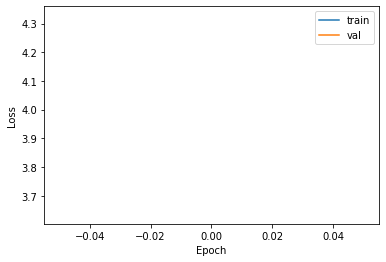

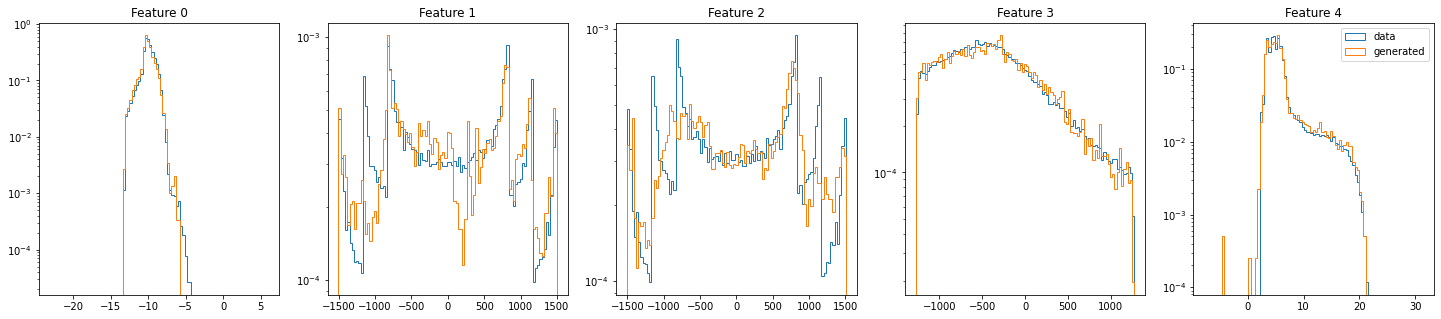

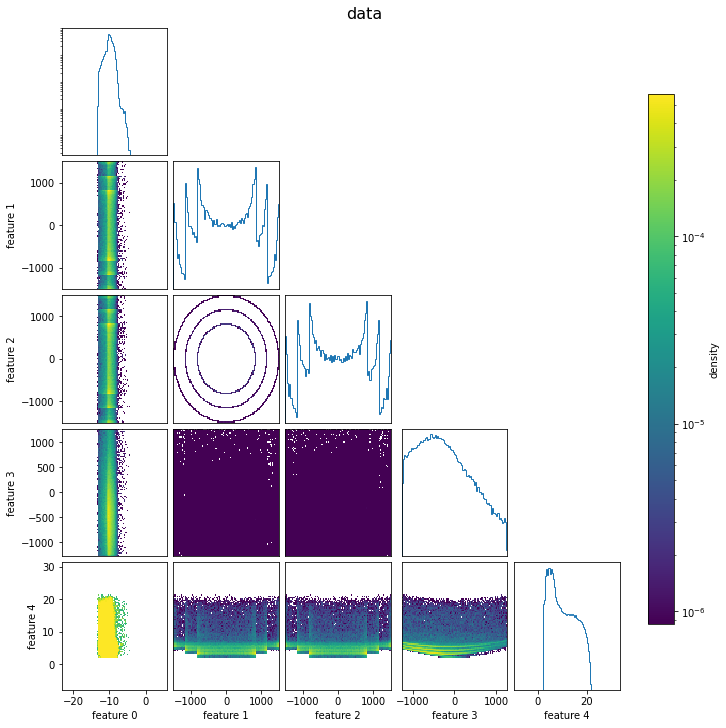

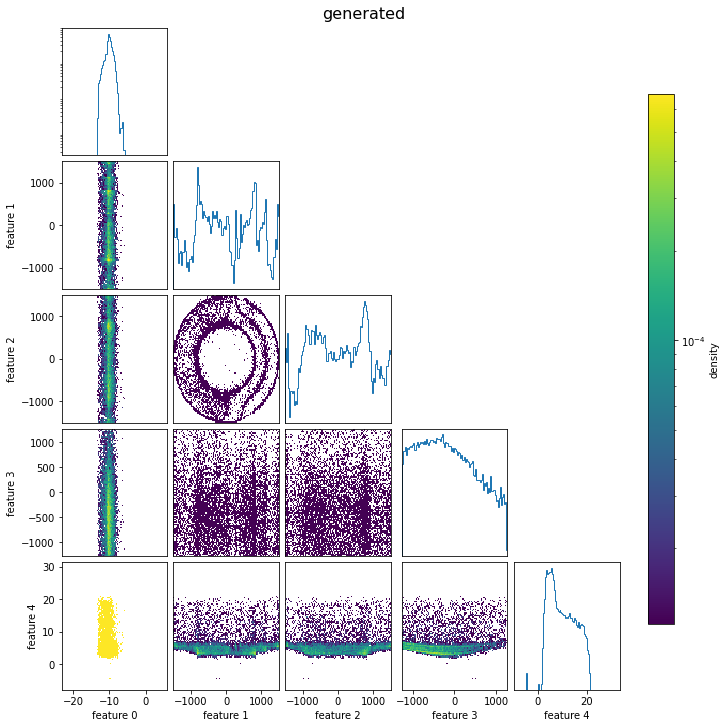

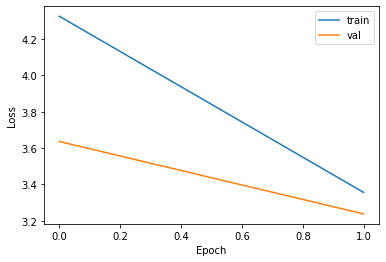

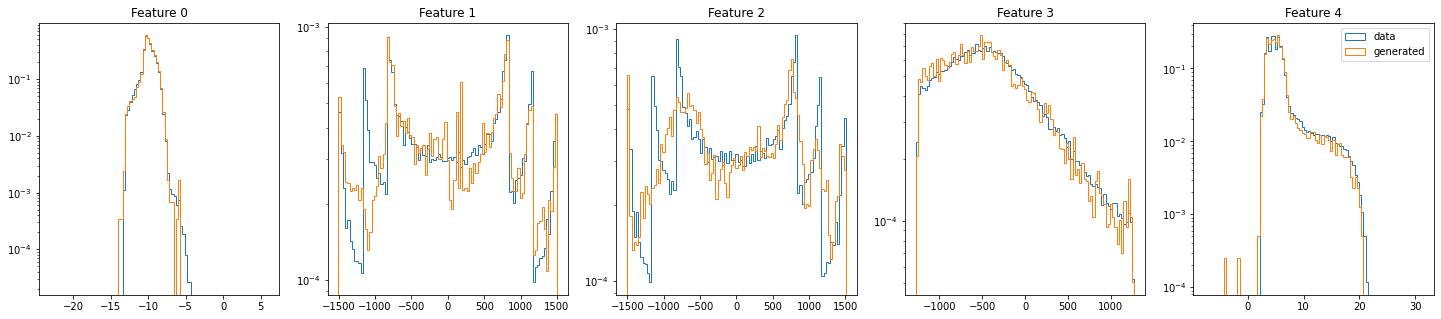

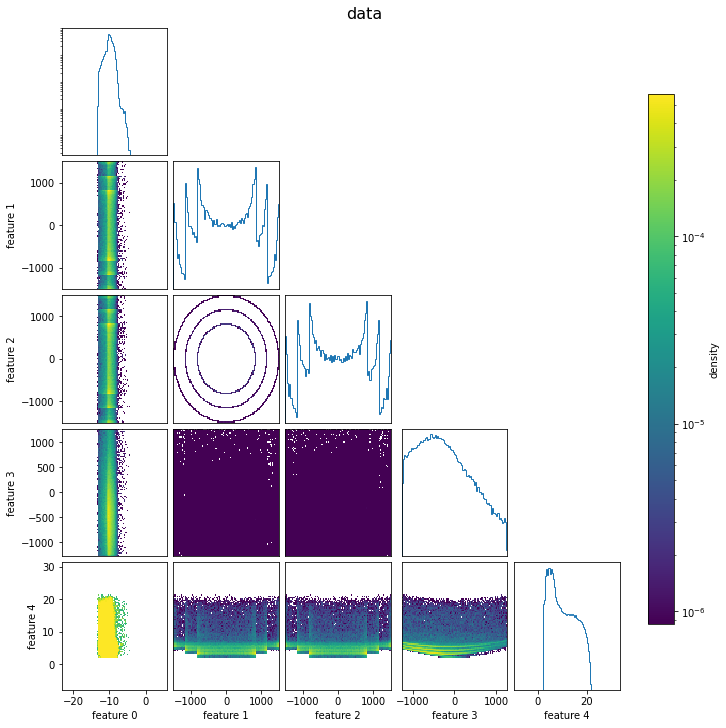

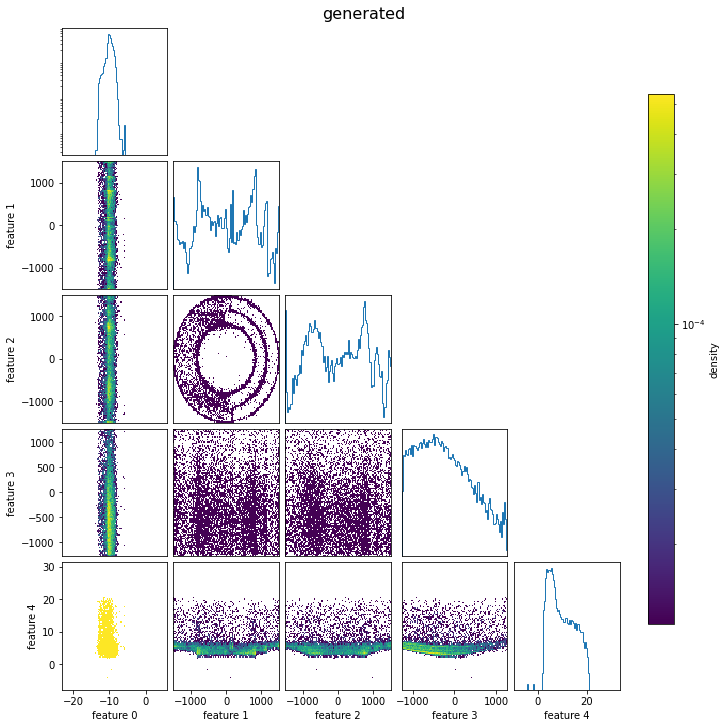

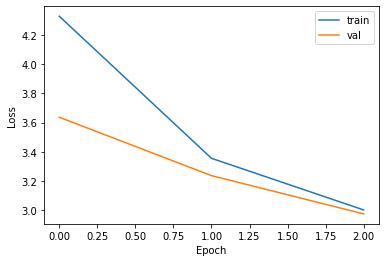

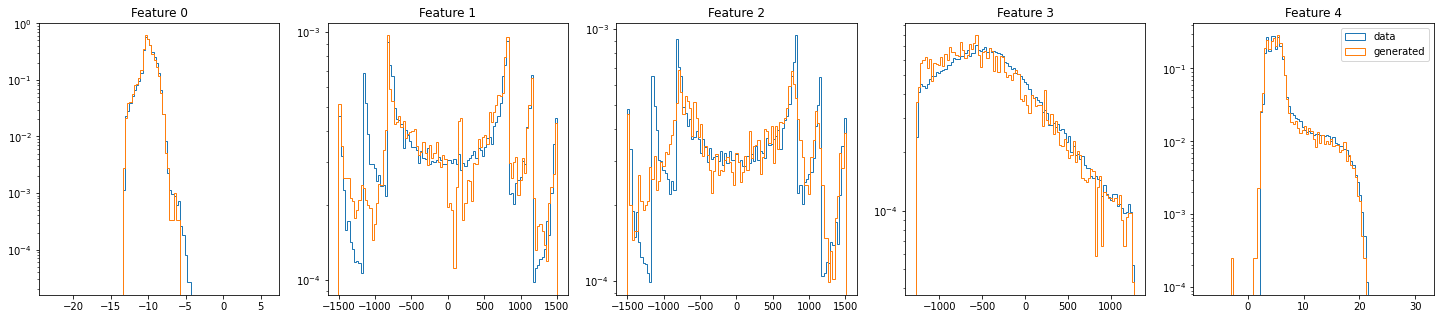

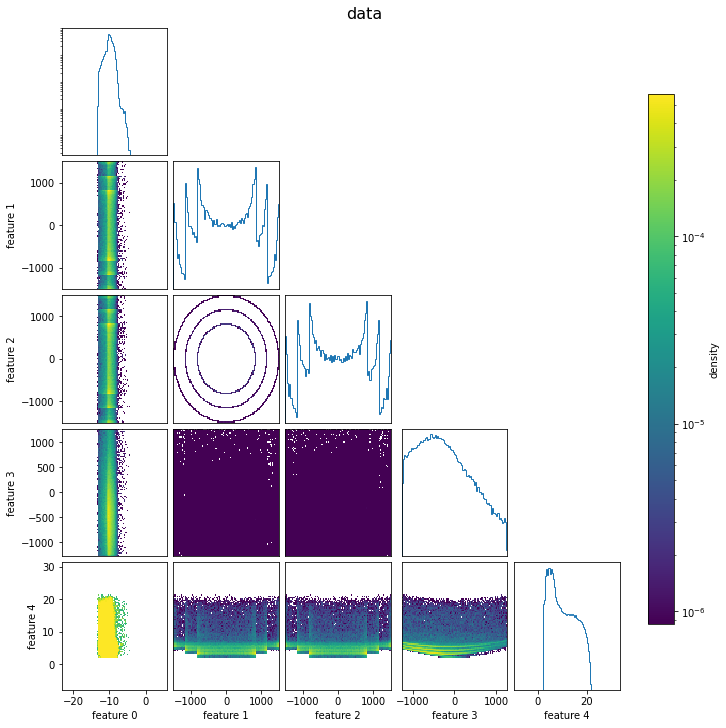

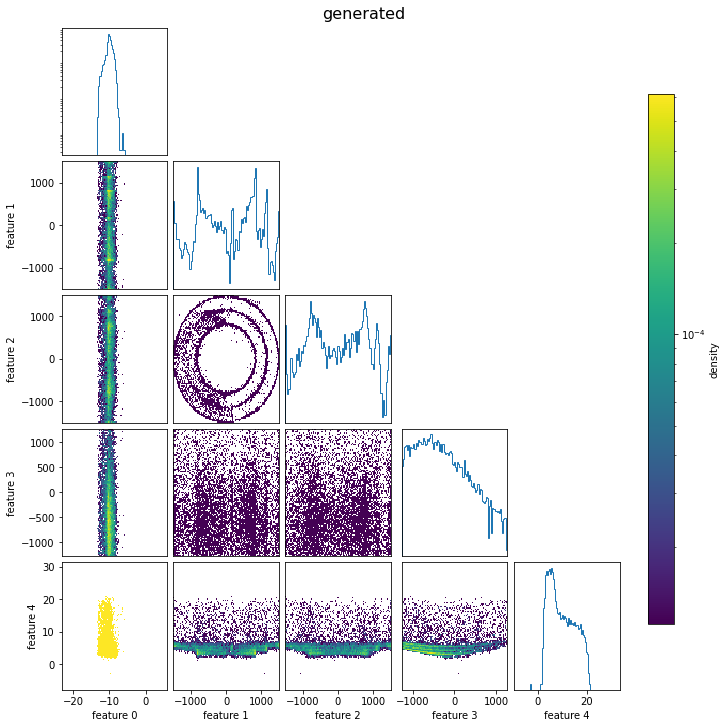

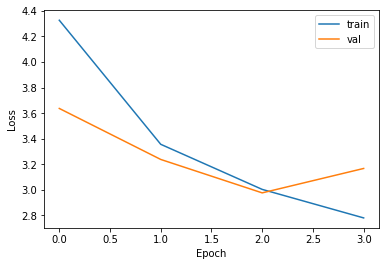

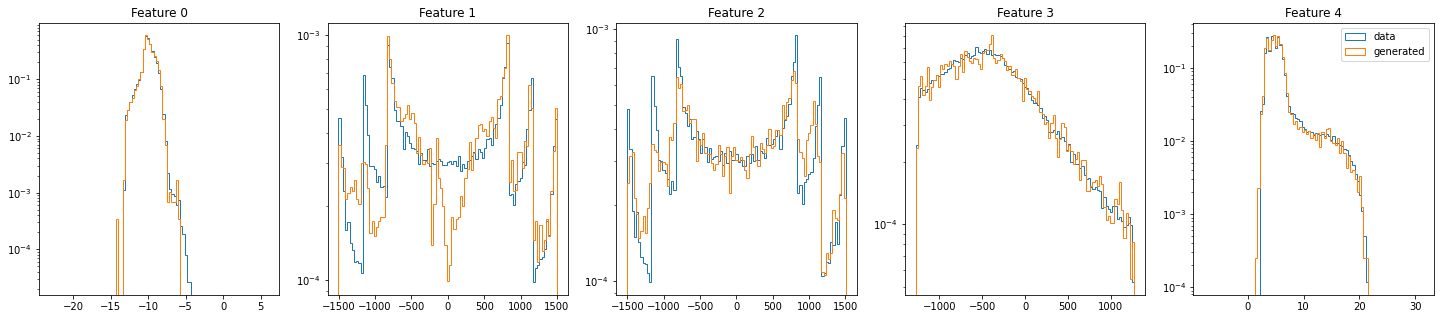

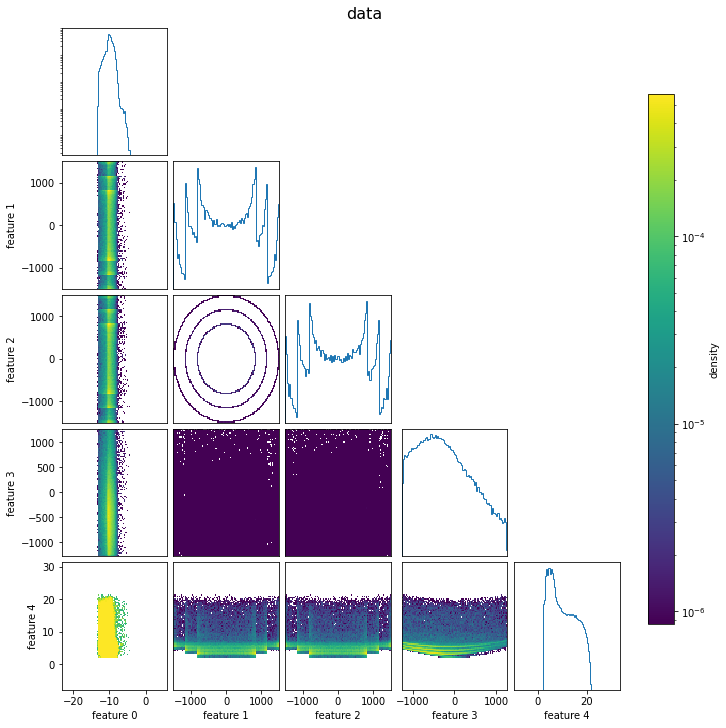

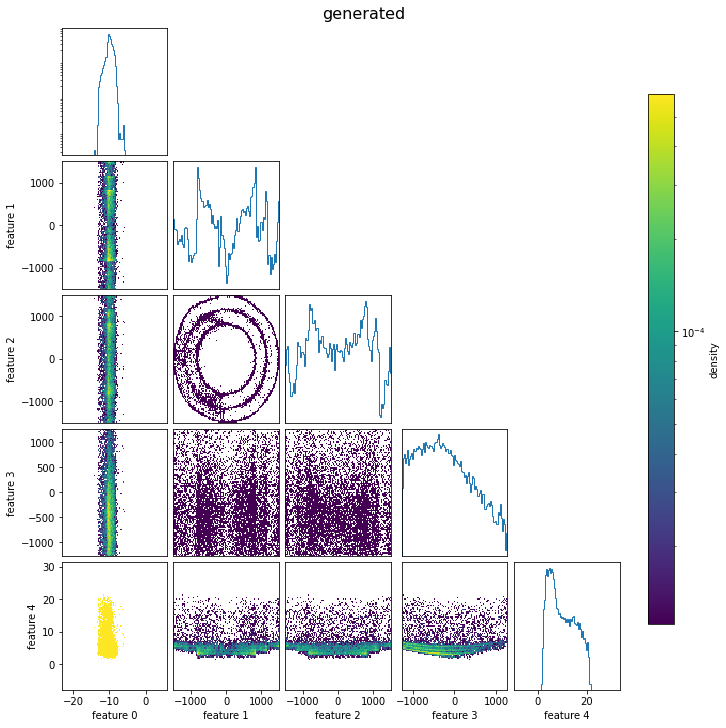

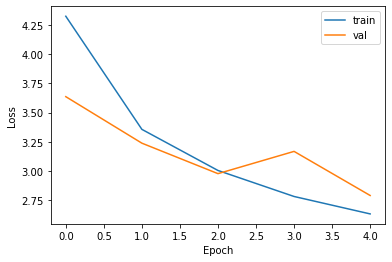

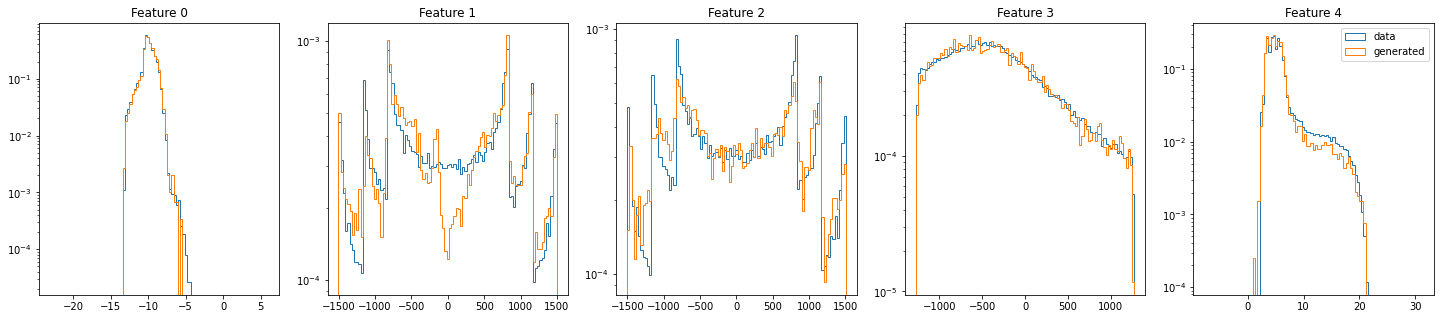

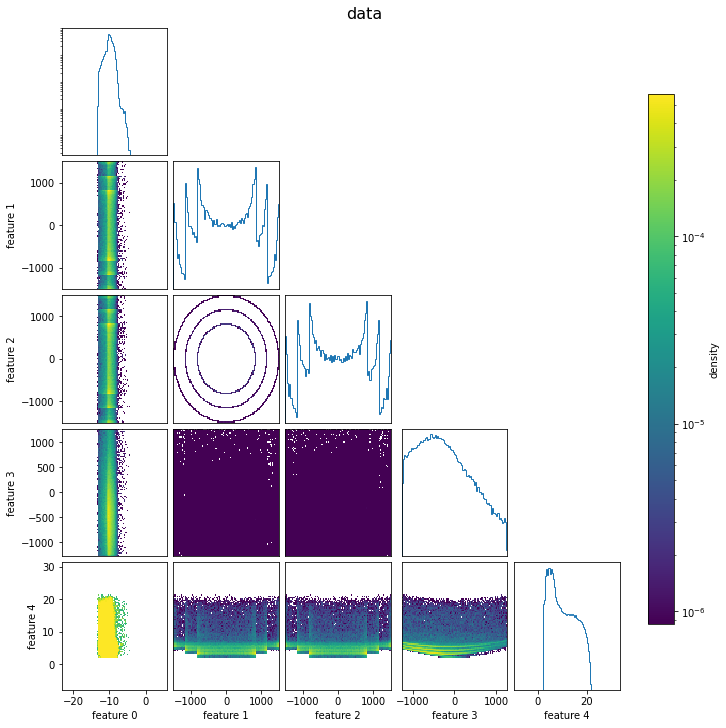

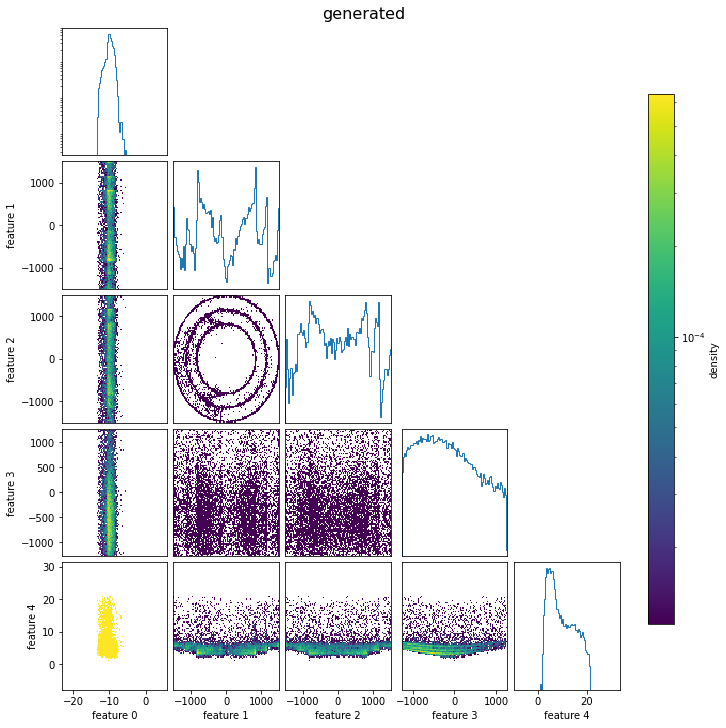

In [12]:
losses_train, losses_val = [], []
best_val_loss = 1e10
        

for k in range(NUM_EPOCHS):

    epoch_losses_train, epoch_losses_val = [], []

    # TRAINING LOOP
    pbar = tqdm(train_loader, desc="Train batches", leave=False, )
    for x in pbar:
        optimizer.zero_grad()

        x = x.to(device).float()

        loss = -flow().log_prob(x).mean()

        epoch_losses_train.append(loss.item())
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=f"{loss.item():.3e}, epoch {k}")

    losses_train.append(np.mean(epoch_losses_train))

    # VALIDATION LOOP
    pbar = tqdm(val_loader, desc="Val batches", leave=False, )
    for x in pbar:

        x = x.to(device).float()
        with torch.no_grad():
            loss = -flow().log_prob(x).mean()
    
        epoch_losses_val.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.3e}, epoch {k}")

    losses_val.append(np.mean(epoch_losses_val))

    if losses_val[-1] < best_val_loss:
        best_val_loss = losses_val[-1]
        #print("new best val loss", losses_val[-1])
        
        torch.save(flow.state_dict(), f"test.pt")

    if (k + 1) % PLOT_EPOCH_INTERVAL == 0:
       
        plt.figure()
        plt.plot(losses_train, label="train")
        plt.plot(losses_val, label="val")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"{save_dir}/losses")

        
        samples = flow().sample((10000,)).detach().cpu().numpy()

            
        loc_data_dict = {"data": inverse_preprocess_data( data_val , "."),
                "generated": inverse_preprocess_data( samples , ".")}
        plot_hists_1d(loc_data_dict, bins_dict, log_dims=log_vars)
        plt.savefig(f"{save_dir}/hists")

        for key in loc_data_dict.keys():
            fig_samp, axes_samp = plot_corner_hist_2d(
                loc_data_dict[key],
                feature_labels=[f"feature {i}" for i in range(NUM_FEATURES)],
                bins_dict=bins_dict,
                log_dims=log_vars,
                title= key,
            )
            plt.savefig(f"{save_dir}/corner_{key}")



In [13]:
# Sample 64 points x ~ p(x | c*)



print("Making flow samples...")

eval_flow = flow

# get epoch of best val loss
#best_epoch = np.nanargmin(val_losses) - 1
#model_path = f"{flow_training_dir}/flow_epoch_{best_epoch}.par"

#eval_model = DensityEstimator(path_to_config_file, NUM_FEATURES, NUM_COND_INPUTS,
#                         eval_mode=True,
#                         load_path=model_path,
#                         device=device, verbose=False,
#                         bound=False)


num_samples_total = data.shape[0] 
sample_batch_size = 8192

samples_flow = []
for i in tqdm(range(0, num_samples_total, sample_batch_size)):
    if i + sample_batch_size > num_samples_total:
        nn = num_samples_total - i 
    else:
        nn = sample_batch_size
    loc_samples = eval_flow().sample((nn,)).detach().cpu().numpy()
    samples_flow.append(loc_samples)
samples_flow = np.concatenate(samples_flow)
print(samples_flow.shape)

    

X_samples = {
        "flow_samples":samples_flow
    }



Making flow samples...


100%|██████████| 80/80 [00:01<00:00, 55.34it/s]

(649005, 5)


In [14]:
for key in X_samples.keys():
    
    X_samples[key] = inverse_preprocess_data( X_samples[key] , ".")


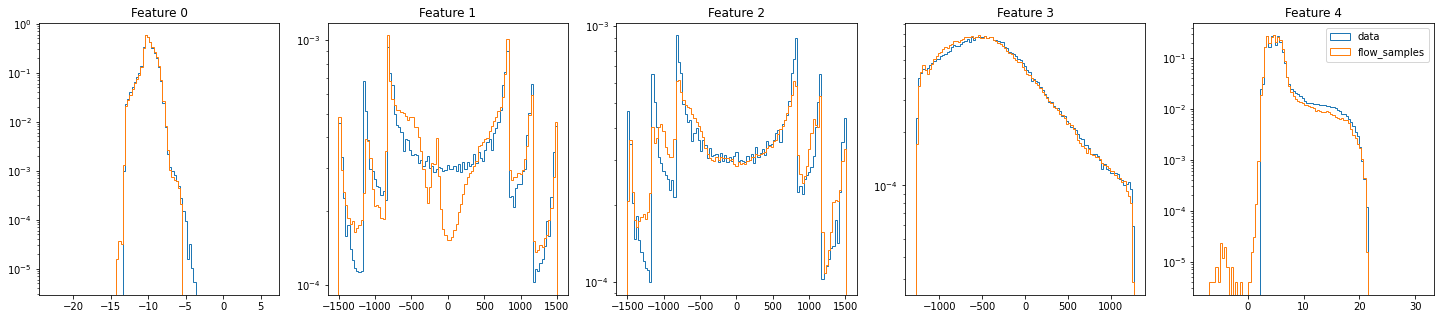

In [15]:

plot_hists_1d({"data":data, **X_samples}, bins_dict, log_dims=log_vars)
plt.savefig(f"{save_dir}/hists_final")


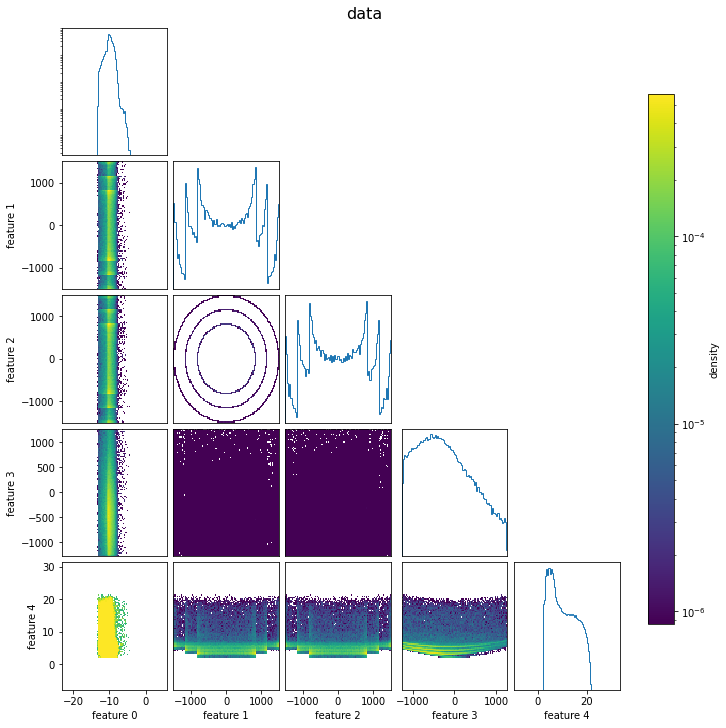

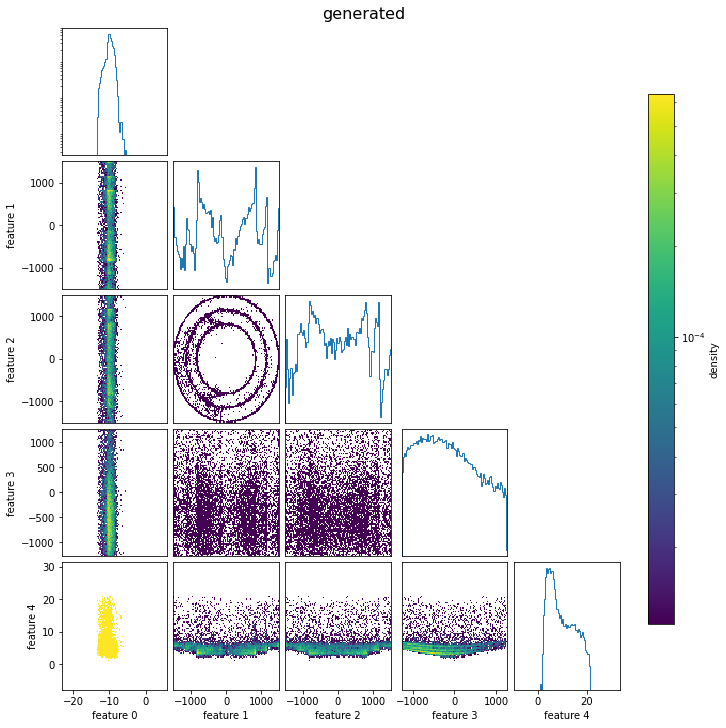

In [16]:
for key in loc_data_dict.keys():
            fig_samp, axes_samp = plot_corner_hist_2d(
                loc_data_dict[key],
                feature_labels=[f"feature {i}" for i in range(NUM_FEATURES)],
                bins_dict=bins_dict,
                log_dims=log_vars,
                title= key,
            )
            plt.savefig(f"{save_dir}/corner_{key}_final")



# Train a BDT to discriminate flow from samples

In [17]:
"""
for key in X_samples.keys():
    
    ks_dists_samples = get_kl_dist(data, X_samples[key])
    ks_dists_gaussians = get_kl_dist(np.random.normal(size = data.shape), np.random.normal(size =  X_samples[key].shape))
    
                                            
    for i, ks_dist in enumerate(ks_dists_samples):
        print("Feature {i} KL div: {ks_dist} (for gaussian: {ks_gauss})".format(i=i, ks_dist=ks_dist, ks_gauss=ks_dists_gaussians[i]))
        
    
    
    auc_mean, auc_std, best_epoch, max_epochs = discriminate_data_from_samples(data,  X_samples[key], n_runs=10, bdt_config="configs/bdt.yml")
    print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch} of {max_epochs}.\n")
    
"""

'\nfor key in X_samples.keys():\n    \n    ks_dists_samples = get_kl_dist(data, X_samples[key])\n    ks_dists_gaussians = get_kl_dist(np.random.normal(size = data.shape), np.random.normal(size =  X_samples[key].shape))\n    \n                                            \n    for i, ks_dist in enumerate(ks_dists_samples):\n        print("Feature {i} KL div: {ks_dist} (for gaussian: {ks_gauss})".format(i=i, ks_dist=ks_dist, ks_gauss=ks_dists_gaussians[i]))\n        \n    \n    \n    auc_mean, auc_std, best_epoch, max_epochs = discriminate_data_from_samples(data,  X_samples[key], n_runs=10, bdt_config="configs/bdt.yml")\n    print(f"auc {auc_mean} \\pm {auc_std}. best epoch {best_epoch} of {max_epochs}.\n")\n    \n'